In [2]:
import pandas as pd

In [3]:
master = pd.read_csv("../data/cleaned/master_dataset.csv")

In [4]:
customer_orders = (
    master
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)

customer_orders.columns = [
    "customer_unique_id",
    "number_of_orders"
]

In [5]:
customer_orders.head()

,customer_unique_id,number_of_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [6]:
repeat_customers = customer_orders[
    customer_orders["number_of_orders"] > 1
]

In [7]:
repeat_purchase_rate = (
    repeat_customers.shape[0]
    /
    customer_orders.shape[0]
) * 100

repeat_purchase_rate

3.1187562437562435

In [8]:
retention_rate = repeat_purchase_rate

retention_rate

3.1187562437562435

In [9]:
churn_rate = 100 - retention_rate

churn_rate

96.88124375624376

In [10]:
average_orders_per_customer = (
    customer_orders["number_of_orders"]
    .mean()
)

average_orders_per_customer

np.float64(1.0348089410589412)

In [11]:
customer_orders[
    "number_of_orders"
].value_counts()

number_of_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

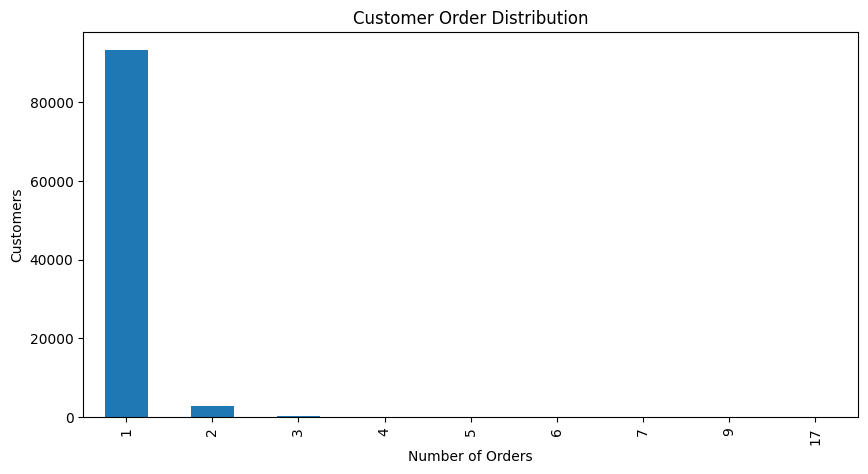

In [12]:
import matplotlib.pyplot as plt

customer_orders[
    "number_of_orders"
].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xlabel("Number of Orders")
plt.ylabel("Customers")
plt.title("Customer Order Distribution")

plt.show()

In [13]:
customer_orders = (
    master.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)

customer_orders.columns = [
    "customer_unique_id",
    "number_of_orders"
]

In [14]:
customer_orders.to_csv(
    "../data/cleaned/customer_orders.csv",
    index=False
)